In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize as opt
import pandas as pd

# Open the data

In [2]:
df_comb = pd.read_csv('data/combined_dataframe.csv')

In [3]:
df_avg_back = pd.read_csv('data/average_background_intensity.csv',index_col=0)

In [4]:
unique_comb = [('WT', 'WT'),
 ('NIPBL', '- dtag'),
 ('NIPBL', '+ dtag'),
 ('WAPL', '- aux'),
 ('WAPL', '+ aux'),
 ('PDS5', '- aux'),
 ('PDS5', '+ aux')]

In [5]:
# compute the iFRAP curves

j = 5
t0 = j*0.5

dfs=[]
ifraps = []
sds = []
for comb in unique_comb: # loop over all combinations of cell type and depletion
    df = df_comb[(df_comb.cell_type == comb[0]) & (df_comb.depletion == comb[1])]
    d = df
    list_sample = []
    print(len(d.nucleus.unique()))
    for i in d.replicate.unique(): # loop over all the images in the combination
        x = np.arange(0,125,0.5)
        correction_bleaching =  df_avg_back[df_avg_back.index == i].values[0] # get the average background intensity for the replicate

        df = d[d.replicate == i].iloc[:,:-3].groupby('frame').mean().reset_index() # average the data over all nuclei in the replicate

        y = ((df.mean_list_interp_unbleached-df.mean_list_interp_bleached)/correction_bleaching)
        norm = y[j]
        y = y/norm # normalize the data to the value at t0
        y = y[j:]
        
        list_sample.append(y.values)
    ifraps.append(np.mean(list_sample,axis=0)) # compute the average iFRAP curve for the combination

    sds.append(np.std(list_sample,axis=0)) # compute the standard deviation iFRAP curve for the combination

18
18
16
23
16
20
12


(0.0, 1.1)

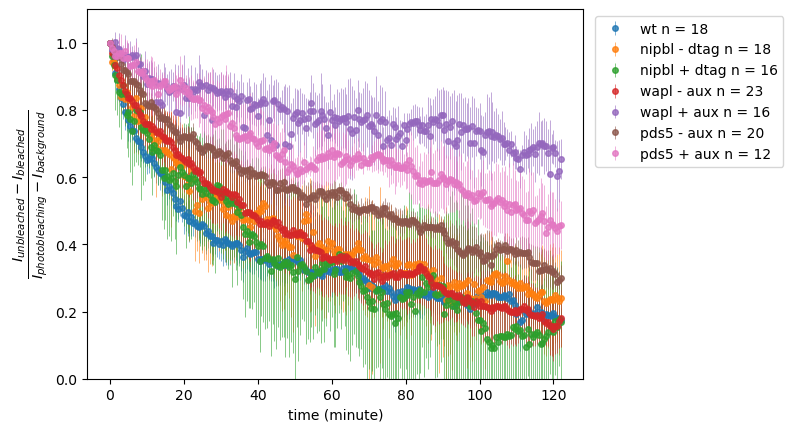

In [6]:
# With error bars

for i,label,s in zip(ifraps,['wt n = 18','nipbl - dtag n = 18','nipbl + dtag n = 16','wapl - aux n = 23','wapl + aux n = 16','pds5 - aux n = 20','pds5 + aux n = 12'],sds):
    plt.errorbar(np.arange(0,((250-j)*0.5),0.5),i,s,label=label,elinewidth=0.5,capsize=0,lw=2,alpha=0.8,linestyle='',marker='o',markersize=4)

plt.legend(bbox_to_anchor=(1.01, 1))
plt.xlabel('time (minute)')
plt.ylabel(r'$\frac{I_{unbleached}-I_{bleached}}{I_{photobleaching}-I_{background}}$',fontsize=15)

plt.ylim(0.0,1.1)


# fit the data

In [7]:
# we weight the fit with the standard deviation, because we normalize to the value at t0 the sd is 0 but to weight the fit we need to set a small value

for s in sds:
    s[0] = 0.0000000000001 # to be able to weight the fitting

In [8]:
def double_exp(t,a,k1,k2):
    return a*np.exp(-k1*(t))+(1-a)*np.exp(-k2*(t))

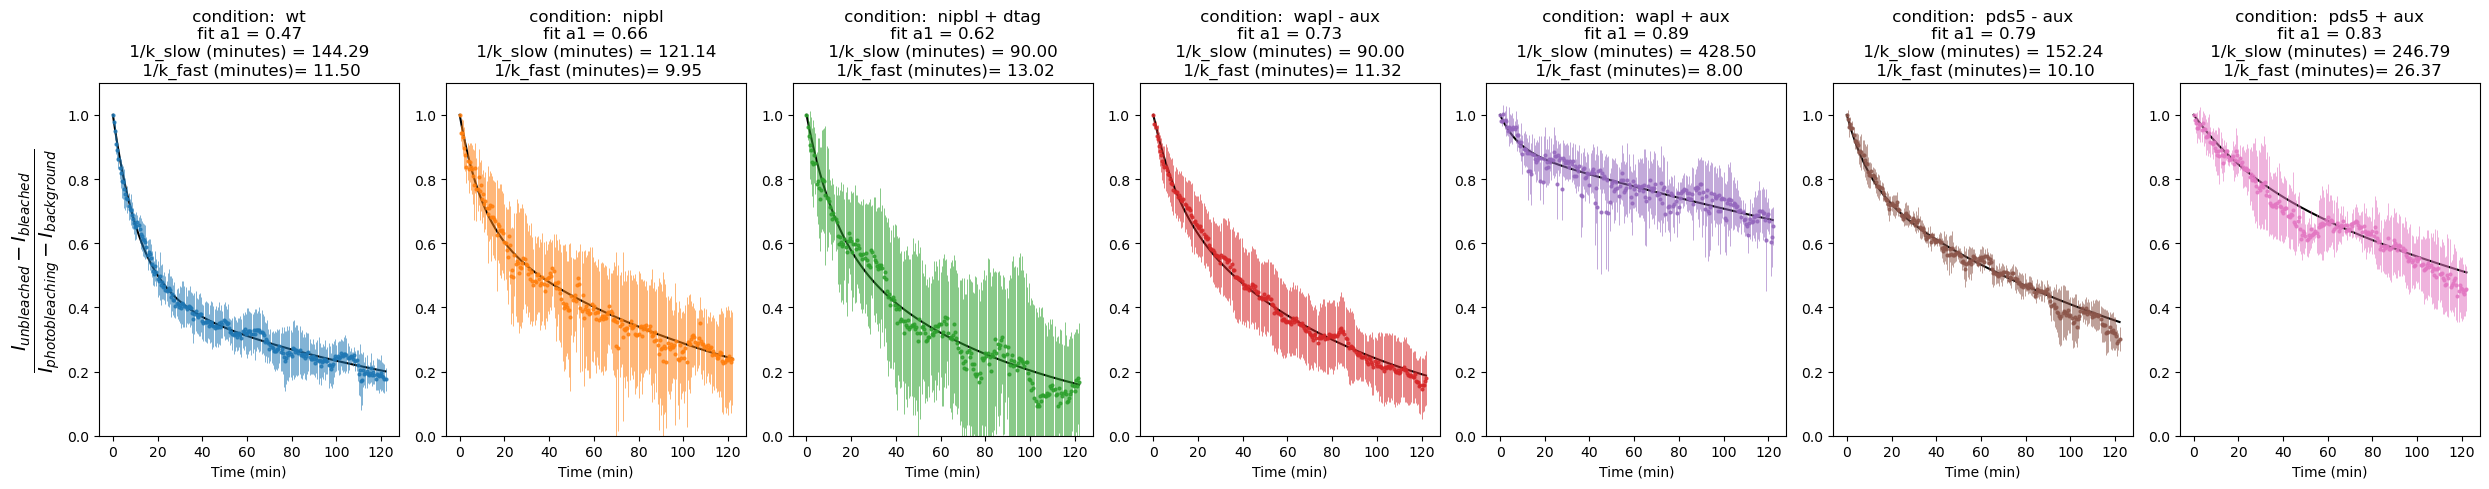

In [9]:
plt.figure(figsize=(25,5))
rate = {'k1':[],'k2':[],'a1':[]}

for (l,i),label,color in zip(enumerate(ifraps),['wt','nipbl','nipbl + dtag','wapl - aux','wapl + aux','pds5 - aux','pds5 + aux'],['tab:blue','tab:orange','tab:green','tab:red','tab:purple','tab:brown','tab:pink']):
    plt.subplot(1,7,l+1)
    if l == 0:
        plt.ylabel(r'$\frac{I_{unbleached}-I_{bleached}}{I_{photobleaching}-I_{background}}$',fontsize=20,fontdict={'name':'dejaVu Sans'})

    y = i
    x = np.arange(0,((250-j)*0.5),0.5)

    popt,pcov = opt.curve_fit(double_exp, x, y,p0=[0.5,1/800,1/8],bounds=([0,1/900,1/30],[1,1/90,1/8]),sigma = sds[l],absolute_sigma=True) # fit the double exponential function to the data with constrains on the rates
    # perr = np.sqrt(np.diag(pcov))

    plt.plot(x,double_exp(x,*popt),label='fit',c='black')
    plt.errorbar(x,y,label='average',c=color,marker='.',yerr=sds[l],elinewidth=0.5,capsize=0,lw=2,alpha=0.8,linestyle='',markersize=4)    
    plt.ylim(0,1.1)
    plt.xlabel('Time (min)')
    plt.title(f' condition:  {label} \n fit a1 = {popt[0]:.2f} \n 1/k_slow (minutes) = {1/popt[1]:.2f} \n 1/k_fast (minutes)= {1/popt[2]:.2f}')
    rate['k1'].append(popt[1])
    rate['k2'].append(popt[2])
    rate['a1'].append(popt[0])


plt.tight_layout()


In [10]:
rates = np.vstack((
                np.array(rate['k1']),
                np.array(rate['k2']),
                np.array(rate['a1']))).T

## lifetime

In [11]:
lifetime = {'wt':[], 'nipbl - dtag':[], 'nipbl + dtag':[], 'wapl - aux':[], 'wapl + aux':[], 'pds5 - aux':[], 'pds5 + aux':[]}
for l,rat in enumerate(rates):

    a = rat[-1]
    k1 = rat[0]
    k2 = rat[1]

    lifetime[list(lifetime.keys())[l]] = a * (1/k1) + (1 - a) * (1/k2) # compute the lifetime from the rates

In [12]:
for condition, times in lifetime.items():
    print(f"{condition}: {times:.2f} minutes")

wt: 73.52 minutes
nipbl - dtag: 83.06 minutes
nipbl + dtag: 60.55 minutes
wapl - aux: 68.55 minutes
wapl + aux: 383.71 minutes
pds5 - aux: 122.34 minutes
pds5 + aux: 209.67 minutes


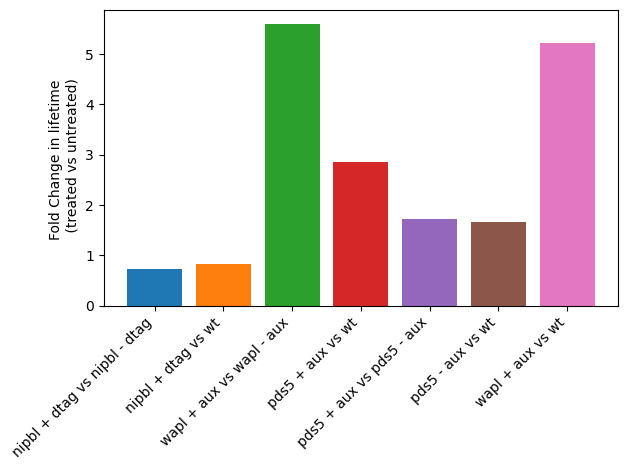

In [13]:
fold_change_hl = {}
# Compute fold change in lifetime for each condition compared to others
for condition in lifetime.keys():
    for c in lifetime.keys():
        if condition != c:
            fold_change_hl[f'{condition} vs {c}'] = lifetime[condition] / lifetime[c]

fold_change_hl_df = pd.DataFrame(fold_change_hl.items(), columns=['Comparison', 'Fold Change'])
fold_change_hl_df.index = fold_change_hl_df['Comparison']
fold_change_hl_df = fold_change_hl_df.drop(columns=['Comparison'])

# filter out the comparisons that are not needed
pairs = [
    ('nipbl + dtag', 'nipbl - dtag'),
    ('nipbl + dtag', 'wt'),
    ('wapl + aux', 'wapl - aux'),
    ('pds5 + aux', 'wt'),
    ('pds5 + aux', 'pds5 - aux'),
    ('pds5 - aux', 'wt'),
    ('wapl + aux', 'wt')]

for idx,pair in enumerate(pairs):
    col1, col2 = pair
    p = fold_change_hl_df.loc[f"{col1} vs {col2}", "Fold Change"]
    plt.bar(idx, p, label=f"{col1} vs {col2}", color=f"C{idx}")

plt.xticks(range(len(pairs)), [f"{col1} vs {col2}" for col1, col2 in pairs], rotation=45, ha='right')
plt.ylabel('Fold Change in lifetime \n (treated vs untreated)')
plt.tight_layout()

In [14]:
# save the pairs as a nice table
df_ = []
for idx,pair in enumerate(pairs):
    col1, col2 = pair
    p = fold_change_hl_df.loc[f"{col1} vs {col2}", "Fold Change"]
    df_.append({
        'Comparison': f"{pair[0]} vs {pair[1]}",
        'Fold Change': p
    })
df_fold_change_lifetime = pd.DataFrame(df_)
df_fold_change_lifetime

,Comparison,Fold Change
0,nipbl + dtag vs nipbl - dtag,0.728989
1,nipbl + dtag vs wt,0.823624
2,wapl + aux vs wapl - aux,5.597432
3,pds5 + aux vs wt,2.851916
4,pds5 + aux vs pds5 - aux,1.713833
5,pds5 - aux vs wt,1.664058
6,wapl + aux vs wt,5.219261


## half life

In [15]:
# to numerically find the time when the function is equal to 0.5, we rewrite the function and solve for f(t) = 0

def func(t):
    return a * np.exp(-k1 * t) + (1 - a) * np.exp(-k2 * t) - 0.5 

half_life = {'wt':[], 'nipbl - dtag':[], 'nipbl + dtag':[], 'wapl - aux':[], 'wapl + aux':[], 'pds5 - aux':[], 'pds5 + aux':[]}
for l,rat in enumerate(rates):

    a = rat[-1]
    k1 = rat[0]
    k2 = rat[1]
    t = np.arange(0,((250-j)*0.5),0.5)
    # Initial guess (try a few values if needed)
    t_guess = 1.0

    # Solve
    t_half = opt.fsolve(func, t_guess)[0]
    half_life[list(half_life.keys())[l]].append(t_half)

print(f" Half life for each condition:")
for condition, times in half_life.items():
    print(f"{condition}: {times[0]:.2f} minutes")

 Half life for each condition:
wt: 20.02 minutes
nipbl - dtag: 35.53 minutes
nipbl + dtag: 27.64 minutes
wapl - aux: 35.83 minutes
wapl + aux: 248.76 minutes
pds5 - aux: 69.64 minutes
pds5 + aux: 126.24 minutes


In [16]:
# compute fold change for each condition

fold_change = {}
for condition in half_life.keys():
    for c in half_life.keys():
        if condition != c:
            fold_change[f'{condition} vs {c}'] = half_life[condition][0] / half_life[c][0]

fold_change_df = pd.DataFrame(fold_change.items(),columns=['Comparison', 'Fold Change'])
fold_change_df.index = fold_change_df['Comparison']
fold_change_df = fold_change_df.drop(columns=['Comparison'])

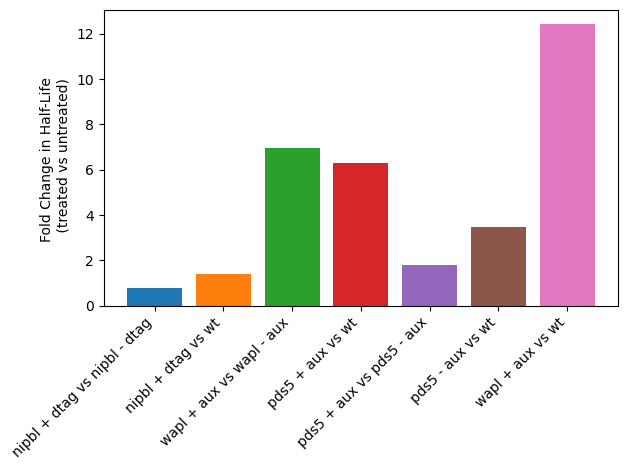

In [17]:
pairs = [
    ('nipbl + dtag', 'nipbl - dtag'),
    ('nipbl + dtag', 'wt'),
    ('wapl + aux', 'wapl - aux'),
    ('pds5 + aux', 'wt'),
    ('pds5 + aux', 'pds5 - aux'),
    ('pds5 - aux', 'wt'),
    ('wapl + aux', 'wt')]

for idx,pair in enumerate(pairs):
    col1, col2 = pair
    p = fold_change_df.loc[f"{col1} vs {col2}", "Fold Change"]
    plt.bar(idx, p, label=f"{col1} vs {col2}", color=f"C{idx}")

plt.xticks(range(len(pairs)), [f"{col1} vs {col2}" for col1, col2 in pairs], rotation=45, ha='right')
plt.ylabel('Fold Change in Half-Life \n (treated vs untreated)')
plt.tight_layout()

In [18]:
# save the pairs as a nice table
df_ = []
for idx,pair in enumerate(pairs):
    col1, col2 = pair
    p = fold_change_df.loc[f"{col1} vs {col2}", "Fold Change"]
    df_.append({
        'Comparison': f"{pair[0]} vs {pair[1]}",
        'Fold Change': p
    })
df_fold_change_hl = pd.DataFrame(df_)
df_fold_change_hl

,Comparison,Fold Change
0,nipbl + dtag vs nipbl - dtag,0.777811
1,nipbl + dtag vs wt,1.380818
2,wapl + aux vs wapl - aux,6.942073
3,pds5 + aux vs wt,6.307136
4,pds5 + aux vs pds5 - aux,1.812868
5,pds5 - aux vs wt,3.479093
6,wapl + aux vs wt,12.428099
